In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from aidan_lib.models.sam3_batched_img import SAM3BatchedImageHarness
import torch
from IPython.display import display

/scratch4/home/adempst/projects/aidan-lib/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/scratch4/home/adempst/projects/aidan-lib/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
harness = SAM3BatchedImageHarness(dtype=torch.bfloat16, model_compile=False)

Building SAM3 image model with torch.bfloat16 precision
Built model, now moving to device cuda with torch.bfloat16 precision
Finished loading model


In [4]:
from aidan_lib.definitions import DATA_DIR

In [5]:
imgs_dir = DATA_DIR / "imgs"
assert imgs_dir.exists()

In [6]:
img_1_path = imgs_dir / "all.png"
img_2_path = imgs_dir / "thompson.png"

In [7]:
from PIL import Image

In [8]:
img_1 = Image.open(img_1_path)
img_2 = Image.open(img_2_path)

In [15]:
out = harness([img_1, img_2]*10, "Person")

In [10]:
out

[SAM3ImageResult(scores=tensor([0.9727, 0.9727], dtype=torch.bfloat16), labels=tensor([1, 1]), boxes=tensor([[ 713.4060,  124.4213, 1367.2817,  809.2383],
         [  -2.1891,  103.2387,  720.7909,  842.7545]]), masks=tensor([[[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]],
 
         [[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]]])),
 SAM3ImageResult(scores=te

In [11]:
mask_img = Image.fromarray(out[6].masks[0].cpu().numpy())
mask_img_2 = Image.fromarray(out[6].masks[1].cpu().numpy())

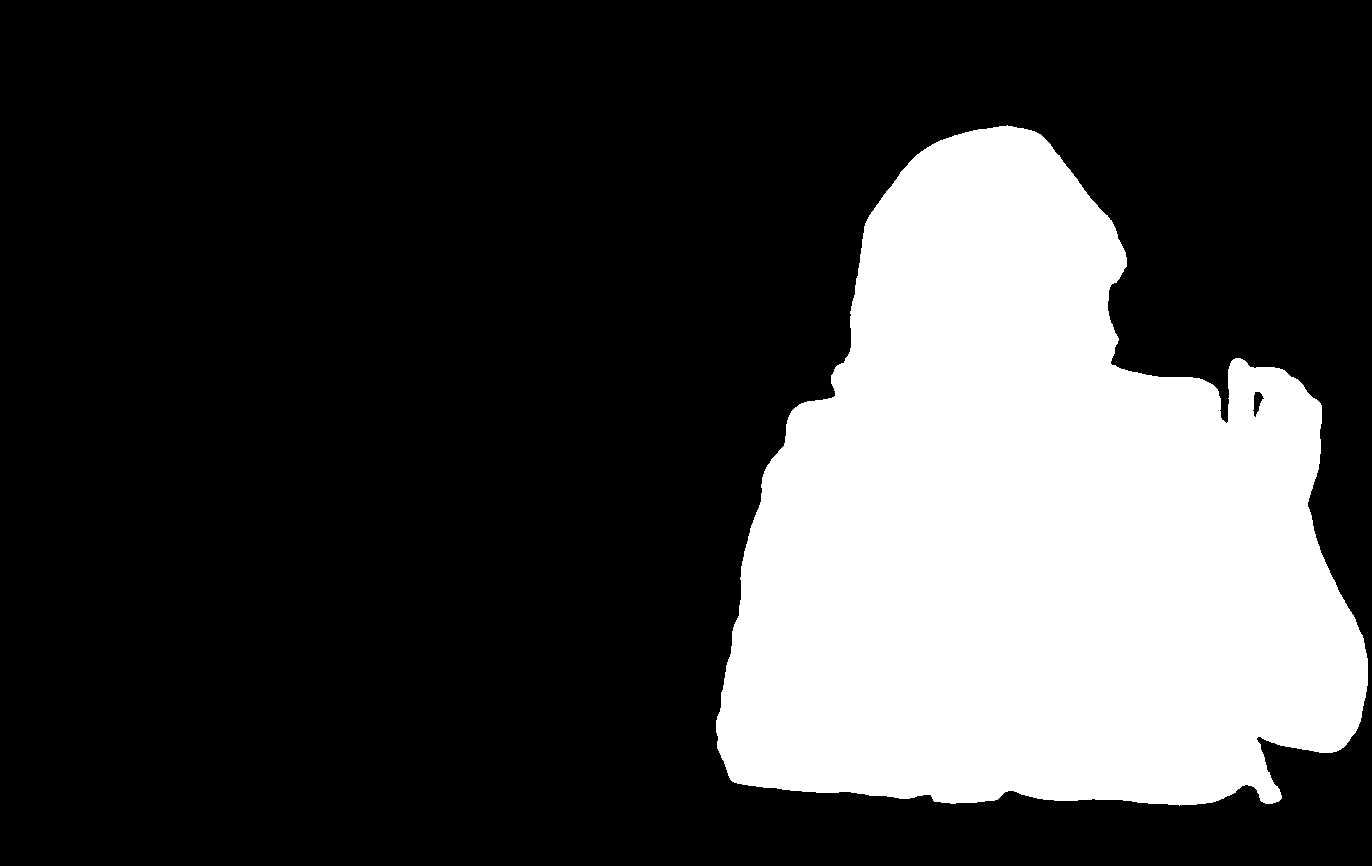

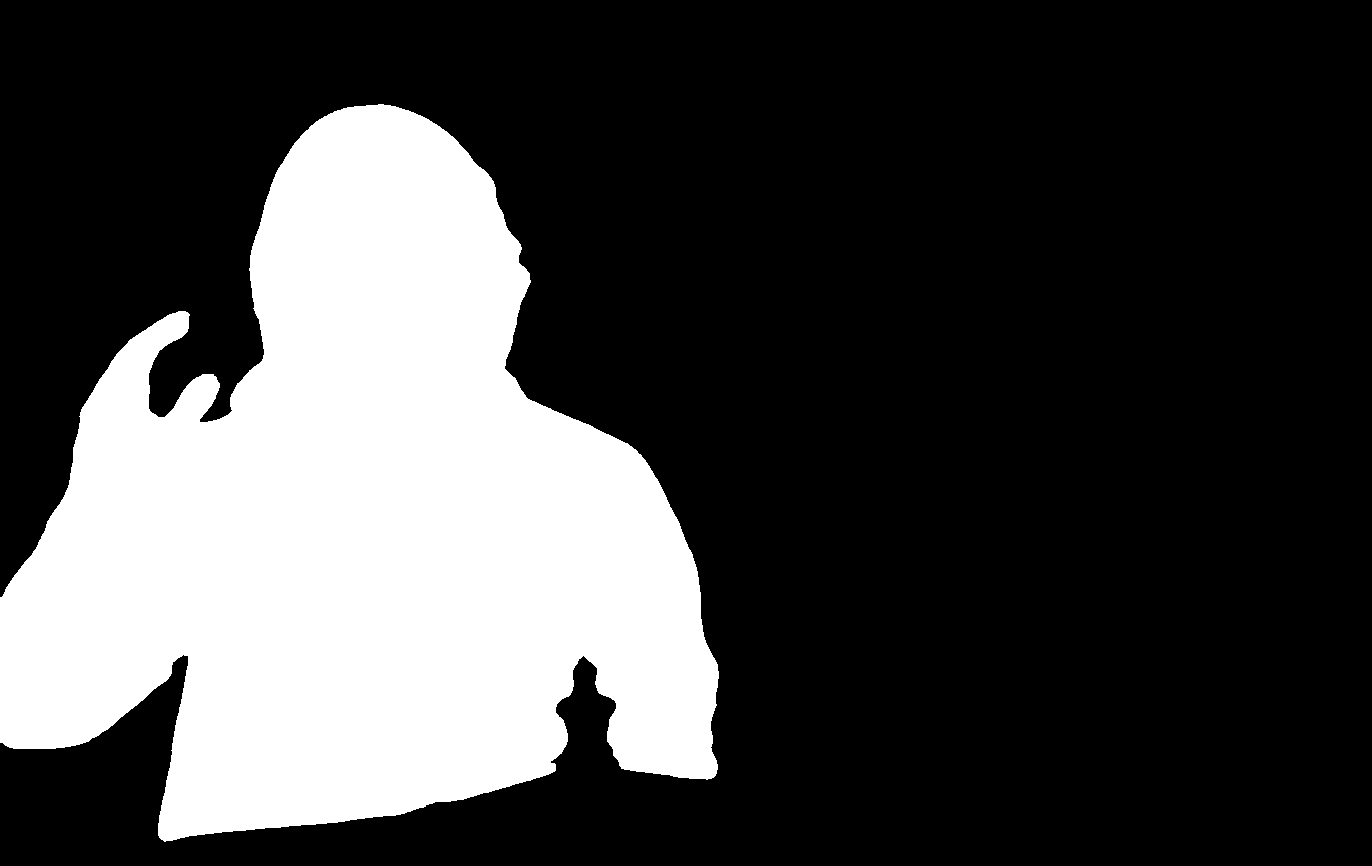

In [12]:
display(mask_img)
display(mask_img_2)